# 📊 Project 1: Customer Sales Cohort & RFM Segmentation Analysis
**Business Domain:** E-commerce Retail & Database Marketing  
**Objective:** Profile user retention behavior and identify high-value customer segments using SQL cohort analysis and RFM (Recency, Frequency, Monetary) modeling.

### Business Context
Customer acquisition costs are rising. To maximize profitability, the business needs to transition from generic marketing to retention-focused campaigns. We need to:
1. Understand **revenue growth trends** and product return rates.
2. Build a **Cohort Retention Matrix** to identify when customers typically churn.
3. Classify customers into actionable **RFM segments** to trigger personalized email campaigns.

---

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Inline plots
%matplotlib inline

# Style config
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    "font.size": 10,
    "figure.figsize": (8, 4.5),
    "axes.edgecolor": "#CBD5E1",
    "axes.facecolor": "#FAFAFA"
})

ACCENT = "#2563EB"
ACCENT_LIGHT = "#93C5FD"
DARK = "#1E293B"
MUTED = "#64748B"


In [2]:
# Initialize DuckDB in-memory database
con = duckdb.connect(database=':memory:')

# Load raw CSV datasets
customers_csv = "customers.csv"
orders_csv = "orders.csv"

# Load into tables
con.execute(f"CREATE TABLE customers AS SELECT * FROM read_csv_auto('{customers_csv}')")
con.execute(f"CREATE TABLE orders AS SELECT * FROM read_csv_auto('{orders_csv}')")

# Confirm counts
print(f"Loaded {con.execute('SELECT COUNT(*) FROM customers').fetchone()[0]} customers.")
print(f"Loaded {con.execute('SELECT COUNT(*) FROM orders').fetchone()[0]} orders.")


Loaded 500 customers.
Loaded 929 orders.


## 📈 Part 1: Monthly Growth & Return Rate Analysis
We first run a SQL query to calculate:
* **Monthly Gross Revenue**
* **Net Completed-Order Revenue** (excluding returned orders)
* **Month-over-Month (MoM) Growth Rate**
* **Monthly Return Rate %** (returned order amount / total order amount)

In [3]:
# Read the SQL query from project SQL file
with open("project1_cohort_retention.sql", "r") as f:
    sql_queries = f.read().split(';')

# Query 1: Monthly Growth
query_1 = sql_queries[0].strip()
print("SQL Query 1:")
print(query_1)

# Execute and get pandas DataFrame
df_revenue = con.execute(query_1).df()
df_revenue

SQL Query 1:
-- ============================================================================
-- SQL Portfolio Project 1: B2B Sales & Customer Cohort Retention Analytics
-- Tool : PostgreSQL, MySQL (8.0+), Snowflake, BigQuery
-- Skills Demonstrated: Common Table Expressions (CTEs), Window Functions,
--                      Date Wrangling, Cohort Analysis, RFM Customer Segmentation.
-- ============================================================================

-- ----------------------------------------------------------------------------
-- TASK 1: Month-over-Month (MoM) Revenue Growth and Return Rate
-- Goal: Analyze e-commerce sales trends, volume, and refund rates MoM.
-- ----------------------------------------------------------------------------
WITH MonthlySales AS (
    SELECT 
        DATE_TRUNC('month', CAST(order_date AS TIMESTAMP)) AS sales_month,
        SUM(CASE WHEN status = 'Completed' THEN amount ELSE 0 END) AS net_revenue,
        COUNT(CASE WHEN status = 'Completed' 

,month,current_month_net_revenue,prior_month_net_revenue,mom_growth_pct,completed_orders,return_rate_pct
0,2025-12,369500.0,NaN,NaN,58,9.94
1,2026-01,607700.0,369500.0,64.47,102,2.51
2,2026-02,715350.0,607700.0,17.71,136,4.29
3,2026-03,1112550.0,715350.0,55.53,178,4.45
4,2026-04,1299400.0,1112550.0,16.79,204,1.52
5,2026-05,1264750.0,1299400.0,-2.67,208,9.98
6,2026-06,3000.0,1264750.0,-99.76,1,0.00


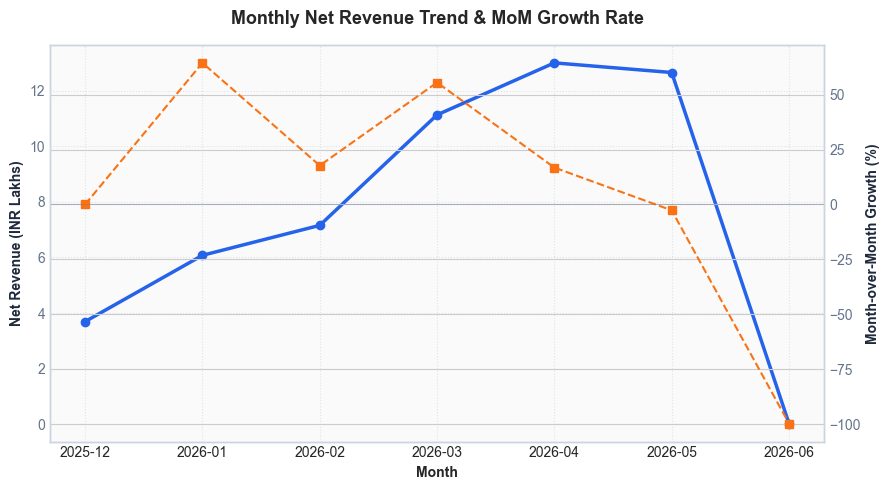

In [4]:
# Plot Monthly Revenue and MoM Growth
fig, ax1 = plt.subplots(figsize=(9, 5))

# Primary Axis: Net Revenue
ax1.plot(df_revenue['month'], df_revenue['current_month_net_revenue'] / 100000, marker='o', color=ACCENT, linewidth=2.5, label='Net Revenue')
ax1.set_ylabel('Net Revenue (INR Lakhs)', color=DARK, fontweight='bold')
ax1.set_xlabel('Month', fontweight='bold')
ax1.tick_params(axis='y', labelcolor=MUTED)
ax1.grid(True, linestyle=':', alpha=0.6, color='#CBD5E1')

# Secondary Axis: MoM Growth %
ax2 = ax1.twinx()
growth_plot = df_revenue['mom_growth_pct'].fillna(0)
ax2.plot(df_revenue['month'], growth_plot, marker='s', color='#F97316', linestyle='--', linewidth=1.5, label='MoM Growth %')
ax2.set_ylabel('Month-over-Month Growth (%)', color=DARK, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=MUTED)
ax2.axhline(0, color=MUTED, linestyle='-', linewidth=0.5, alpha=0.5)

plt.title('Monthly Net Revenue Trend & MoM Growth Rate', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 🔄 Part 2: Cohort Retention Matrix
We aggregate customers into monthly cohorts based on their `signup_date` (Month 0) and track the percentage of those customers who return to purchase in subsequent months (Period 1 to Period 5).

In [5]:
# Query 2: Cohort Retention
query_2 = sql_queries[1].strip()
print("SQL Query 2 (Cohort Retention):")
df_retention = con.execute(query_2).df()
df_retention

SQL Query 2 (Cohort Retention):


,cohort,cohort_size,period_0_pct,period_1_pct,period_2_pct,period_3_pct,period_4_pct,period_5_pct
0,2025-12,73,71.2,46.6,43.8,39.7,28.8,16.4
1,2026-01,78,71.8,34.6,42.3,28.2,21.8,0.0
2,2026-02,86,79.1,39.5,47.7,30.2,0.0,0.0
3,2026-03,92,67.4,43.5,38.0,0.0,0.0,0.0
4,2026-04,84,69.0,40.5,0.0,0.0,0.0,0.0
5,2026-05,87,77.0,1.1,0.0,0.0,0.0,0.0


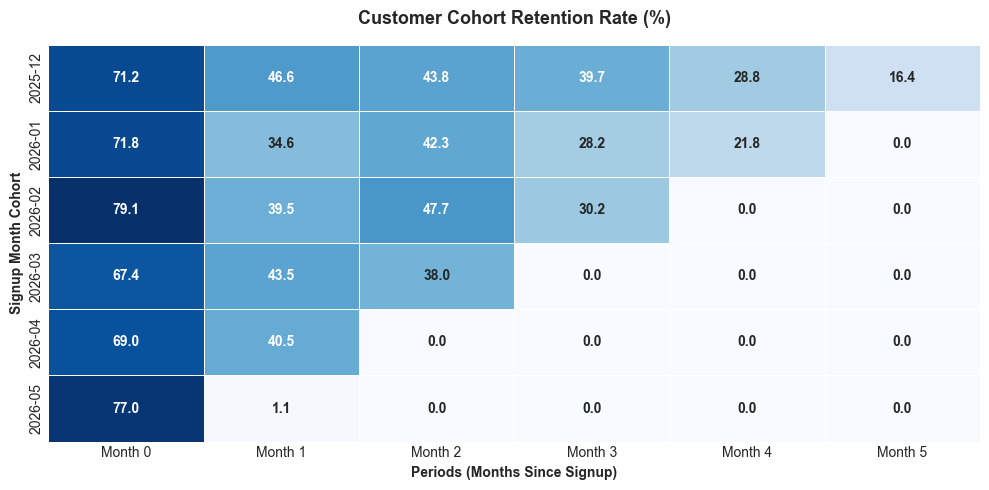

In [6]:
# Plot Retention Heatmap
plt.figure(figsize=(10, 5))
heatmap_data = df_retention.set_index('cohort')[[c for c in df_retention.columns if 'pct' in c]]
heatmap_data.columns = [f"Month {c.split('_')[1]}" for c in heatmap_data.columns]

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Blues", cbar=False, 
            annot_kws={"size": 10, "weight": "bold"}, linewidths=0.5)
plt.title('Customer Cohort Retention Rate (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Periods (Months Since Signup)', fontweight='bold')
plt.ylabel('Signup Month Cohort', fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 Part 3: RFM Customer Segmentation
We run an RFM model using SQL window functions and NTILE:
1. **Recency**: Days since last order (Lower is better $ightarrow$ Higher score)
2. **Frequency**: Count of completed orders (Higher is better $ightarrow$ Higher score)
3. **Monetary**: Sum of order amounts (Higher is better $ightarrow$ Higher score)
4. Score segments based on code combinations.

In [7]:
# Query 3: RFM Segmentation
query_3 = sql_queries[2].strip()
df_rfm = con.execute(query_3).df()
print("Top 10 Customers Segmented:")
df_rfm.head(10)

Top 10 Customers Segmented:


,customer_id,recency_days,frequency_count,monetary_value,rfm_code,customer_segment
0,381,68.0,5,77450.0,255,"At Risk (High Value, Sleeping)"
1,366,19.0,6,77150.0,455,Champions (Loyal High-Spenders)
2,232,29.0,5,70250.0,355,Regular Mid-Tier Customers
3,208,13.0,4,66350.0,455,Champions (Loyal High-Spenders)
4,63,10.0,3,65400.0,545,Champions (Loyal High-Spenders)
5,312,57.0,4,60600.0,255,"At Risk (High Value, Sleeping)"
6,175,37.0,5,58600.0,355,Regular Mid-Tier Customers
7,353,67.0,4,56800.0,255,"At Risk (High Value, Sleeping)"
8,372,21.0,6,54400.0,455,Champions (Loyal High-Spenders)
9,164,6.0,4,54100.0,555,Champions (Loyal High-Spenders)


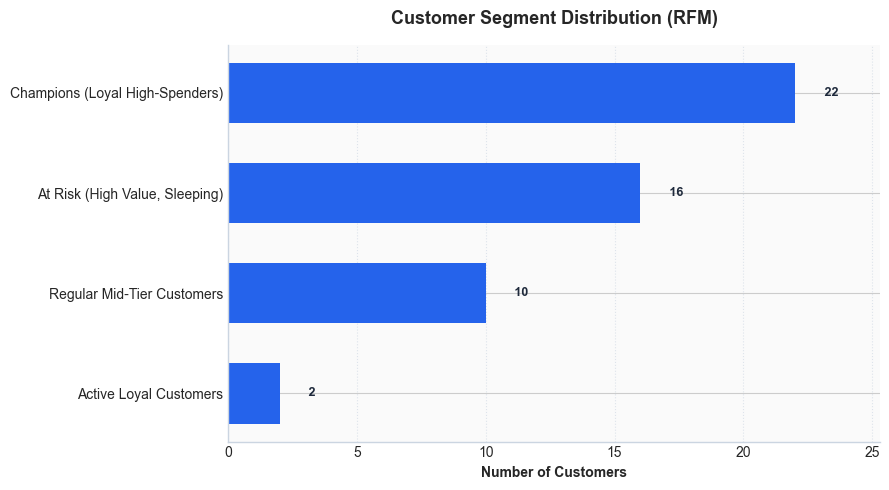

In [8]:
# Plot RFM Segment Distribution
plt.figure(figsize=(9, 5))
segment_counts = df_rfm['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']
segment_counts = segment_counts.sort_values(by='Customer Count', ascending=True)

bars = plt.barh(segment_counts['Segment'], segment_counts['Customer Count'], color=ACCENT, height=0.6)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f' {int(width)}', 
             va='center', ha='left', fontsize=9, fontweight='bold', color=DARK)
             
plt.title('Customer Segment Distribution (RFM)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontweight='bold')
plt.xlim(0, segment_counts['Customer Count'].max() * 1.15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle=':', alpha=0.6, color='#CBD5E1')
plt.tight_layout()
plt.show()

## 💡 Part 4: Business Insights & Recommendations
Based on the analysis, here are the recommendations:
1. **At Risk Retention:** Retarget the **"At Risk (High Value, Sleeping)"** segment with a reactivation discount code. These are historical high spenders who haven't purchased recently.
2. **Loyalty Program:** Reward **"Champions"** with exclusive early access to product releases to build brand advocacy.
3. **Retention Bottleneck:** Cohort Month 1 drops significantly. Investigate the onboarding process or initial product experience to improve first-month retention.
